In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
tf.config.run_functions_eagerly(True) # This ensures eager execution within tf.function
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

2025-06-23 23:01:03.774621: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750719663.816730      86 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750719663.829671      86 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
num_samples = 60000
X_train = X_train[ : num_samples ]
y_train = y_train[ : num_samples ]
print ( X_train.shape )

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)


In [4]:
print('X_train.shape', X_train.shape)

# Reshape and normalize
X_train = X_train.reshape( X_train.shape[0], 28, 28, 1 ).astype('float32')
X_train = ( X_train / 255 - 0.5 ) * 2
print('X_train reshape:', X_train.shape)

# Batch and shuffle the data
batch_size = 256
train_dataset = tf.data.Dataset.from_tensor_slices( X_train ).shuffle(num_samples).batch( batch_size )

X_train.shape (60000, 28, 28)
X_train reshape: (60000, 28, 28, 1)


I0000 00:00:1750719669.665838      86 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


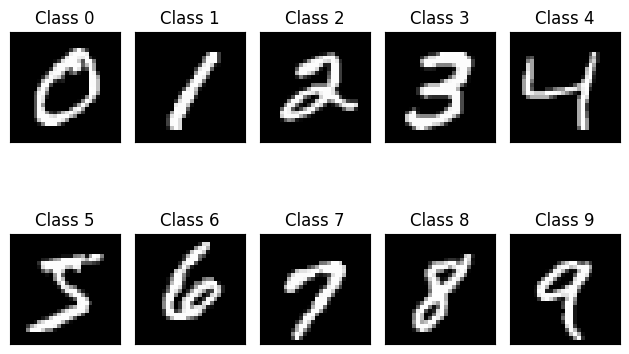

In [5]:
fig = plt.figure()
for i in range(10):
    plt.subplot(2, 5, i+1)
    x_y = X_train[y_train == i]
    plt.imshow(x_y[0], cmap='gray', interpolation='none')
    plt.title("Class %d" % (i))
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

In [6]:
latent_dim = 100
def generator_model():
    model = tf.keras.Sequential()
    model.add( tf.keras.Input( shape=(latent_dim,) ) )
    model.add(layers.Dense( 7*7*256, use_bias=False ) )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)  # Note: None is the batch size

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model
generator = generator_model()

In [7]:
def discriminator_model():
    model = tf.keras.Sequential()
    model.add( tf.keras.Input( shape=[28, 28, 1] ) )
    model.add( layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same') )
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add( layers.Dense(1, activation='sigmoid') )

    return model
discriminator = discriminator_model()

I0000 00:00:1750719673.362889      86 cuda_dnn.cc:529] Loaded cuDNN version 90300


Epoch: 0, disc. loss: 0.6736308932304382, gen. loss: 0.808891773223877. Time for epoch 1 is 54.31486201286316 sec
Epoch: 1, disc. loss: 0.6357230544090271, gen. loss: 0.7080325484275818. Time for epoch 2 is 49.08099055290222 sec
Epoch: 2, disc. loss: 0.5964959263801575, gen. loss: 1.1140494346618652. Time for epoch 3 is 46.82740020751953 sec
Epoch: 3, disc. loss: 0.6966426372528076, gen. loss: 0.7015889883041382. Time for epoch 4 is 47.34070682525635 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


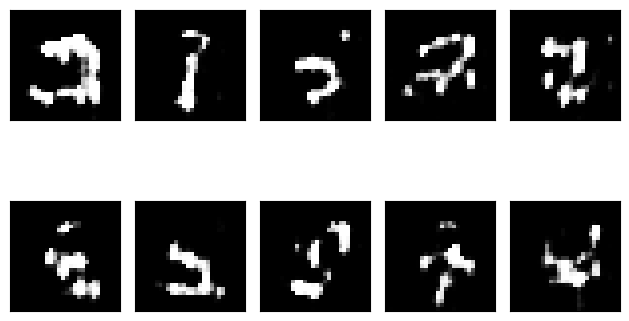

Epoch: 4, disc. loss: 0.6367189884185791, gen. loss: 0.8214437365531921. Time for epoch 5 is 48.002970933914185 sec
Epoch: 5, disc. loss: 0.6244411468505859, gen. loss: 0.8989183306694031. Time for epoch 6 is 46.437561988830566 sec
Epoch: 6, disc. loss: 0.6241439580917358, gen. loss: 0.826133668422699. Time for epoch 7 is 47.61883735656738 sec
Epoch: 7, disc. loss: 0.6132943630218506, gen. loss: 0.9047940969467163. Time for epoch 8 is 46.05844593048096 sec
Epoch: 8, disc. loss: 0.6735237240791321, gen. loss: 0.6800428628921509. Time for epoch 9 is 46.115516901016235 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


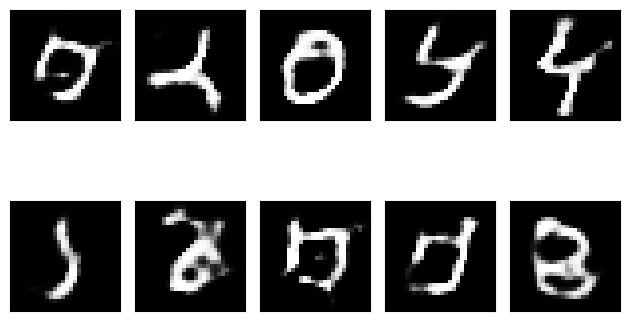

Epoch: 9, disc. loss: 0.633209228515625, gen. loss: 0.6819196939468384. Time for epoch 10 is 46.63567399978638 sec
Epoch: 10, disc. loss: 0.6646180152893066, gen. loss: 0.7284477353096008. Time for epoch 11 is 47.356024503707886 sec
Epoch: 11, disc. loss: 0.6794677972793579, gen. loss: 0.6884844303131104. Time for epoch 12 is 48.829686641693115 sec
Epoch: 12, disc. loss: 0.650139570236206, gen. loss: 0.6905472278594971. Time for epoch 13 is 47.792070150375366 sec
Epoch: 13, disc. loss: 0.6791118383407593, gen. loss: 0.5833402276039124. Time for epoch 14 is 47.561219692230225 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


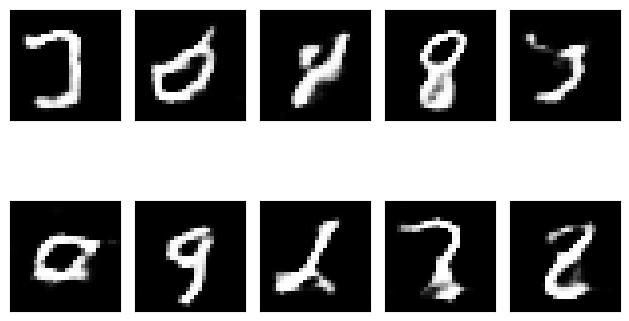

Epoch: 14, disc. loss: 0.6488749980926514, gen. loss: 0.9614841341972351. Time for epoch 15 is 47.18609857559204 sec
Epoch: 15, disc. loss: 0.6693273782730103, gen. loss: 0.6440960764884949. Time for epoch 16 is 46.351067543029785 sec
Epoch: 16, disc. loss: 0.6202350854873657, gen. loss: 0.8226576447486877. Time for epoch 17 is 47.57503414154053 sec
Epoch: 17, disc. loss: 0.6786600351333618, gen. loss: 0.7753766775131226. Time for epoch 18 is 48.085928201675415 sec
Epoch: 18, disc. loss: 0.705781102180481, gen. loss: 0.7699257135391235. Time for epoch 19 is 47.79158639907837 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


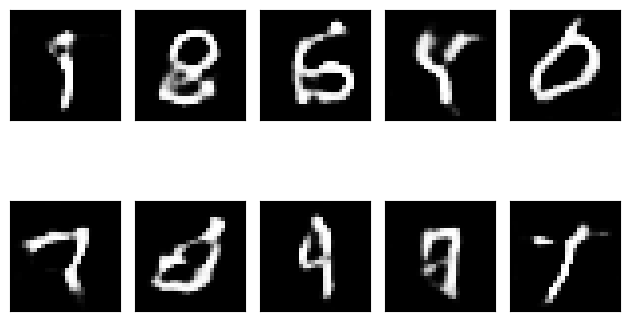

Epoch: 19, disc. loss: 0.6295394897460938, gen. loss: 0.789128303527832. Time for epoch 20 is 47.474982500076294 sec
Epoch: 20, disc. loss: 0.63625168800354, gen. loss: 0.9349502325057983. Time for epoch 21 is 46.72460222244263 sec
Epoch: 21, disc. loss: 0.6593908071517944, gen. loss: 0.8185369968414307. Time for epoch 22 is 47.329195737838745 sec
Epoch: 22, disc. loss: 0.6990507245063782, gen. loss: 0.8879464268684387. Time for epoch 23 is 46.50507879257202 sec
Epoch: 23, disc. loss: 0.6150271892547607, gen. loss: 0.8318642973899841. Time for epoch 24 is 47.26461124420166 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


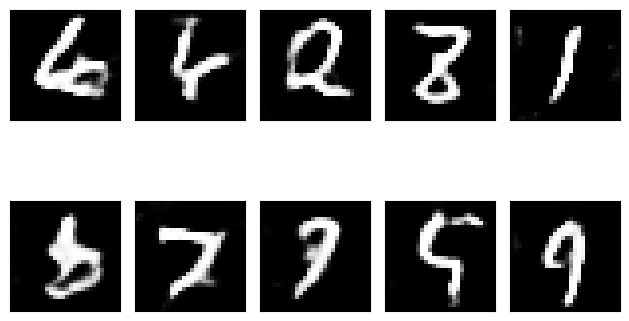

Epoch: 24, disc. loss: 0.6908835172653198, gen. loss: 0.726459264755249. Time for epoch 25 is 47.96475172042847 sec
Epoch: 25, disc. loss: 0.6396099328994751, gen. loss: 0.7426972389221191. Time for epoch 26 is 47.604369163513184 sec
Epoch: 26, disc. loss: 0.6859513521194458, gen. loss: 0.6886256337165833. Time for epoch 27 is 47.81753587722778 sec
Epoch: 27, disc. loss: 0.6536381244659424, gen. loss: 0.7195332646369934. Time for epoch 28 is 47.89934849739075 sec
Epoch: 28, disc. loss: 0.6029186248779297, gen. loss: 0.7502185702323914. Time for epoch 29 is 47.502291202545166 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


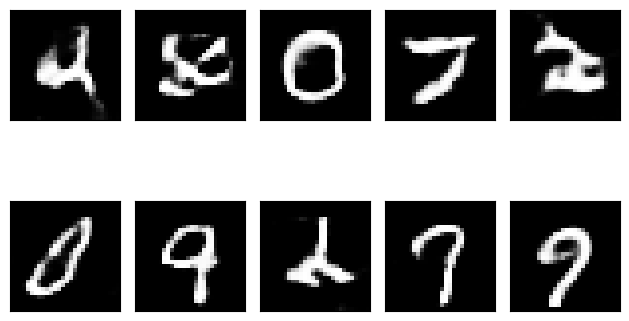

Epoch: 29, disc. loss: 0.663292407989502, gen. loss: 0.7888727188110352. Time for epoch 30 is 47.181193828582764 sec
Epoch: 30, disc. loss: 0.6561602354049683, gen. loss: 0.7895050644874573. Time for epoch 31 is 46.11862111091614 sec
Epoch: 31, disc. loss: 0.6723922491073608, gen. loss: 0.6868311762809753. Time for epoch 32 is 45.691757917404175 sec
Epoch: 32, disc. loss: 0.6243596076965332, gen. loss: 0.7236178517341614. Time for epoch 33 is 46.03509211540222 sec
Epoch: 33, disc. loss: 0.6788678169250488, gen. loss: 0.6681017279624939. Time for epoch 34 is 46.6955771446228 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


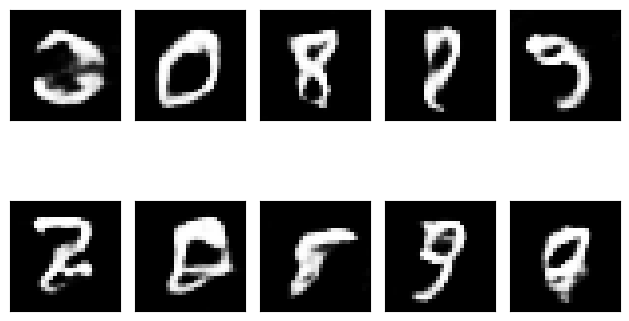

Epoch: 34, disc. loss: 0.6406015157699585, gen. loss: 0.8291094899177551. Time for epoch 35 is 47.26227426528931 sec
Epoch: 35, disc. loss: 0.6347630023956299, gen. loss: 0.8662786483764648. Time for epoch 36 is 46.333250999450684 sec
Epoch: 36, disc. loss: 0.6653581261634827, gen. loss: 0.7631325721740723. Time for epoch 37 is 46.31896114349365 sec
Epoch: 37, disc. loss: 0.6379653215408325, gen. loss: 0.7690736651420593. Time for epoch 38 is 45.26897406578064 sec
Epoch: 38, disc. loss: 0.5967203378677368, gen. loss: 0.7481619119644165. Time for epoch 39 is 45.656347036361694 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


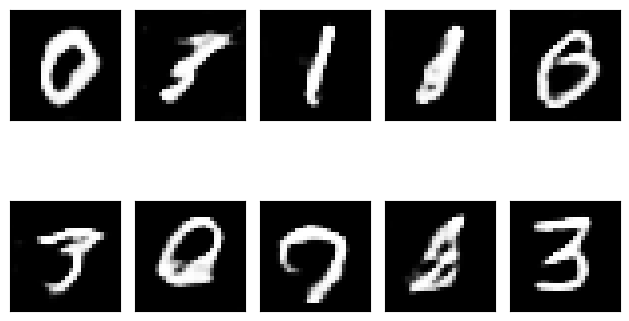

Epoch: 39, disc. loss: 0.7142505645751953, gen. loss: 0.6466504335403442. Time for epoch 40 is 45.35371255874634 sec
Epoch: 40, disc. loss: 0.6254533529281616, gen. loss: 0.7881911993026733. Time for epoch 41 is 44.81334376335144 sec
Epoch: 41, disc. loss: 0.6606670618057251, gen. loss: 0.7411247491836548. Time for epoch 42 is 44.74571633338928 sec
Epoch: 42, disc. loss: 0.6770012378692627, gen. loss: 0.7629445195198059. Time for epoch 43 is 44.67344427108765 sec
Epoch: 43, disc. loss: 0.6311839818954468, gen. loss: 0.8335727453231812. Time for epoch 44 is 44.696359157562256 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


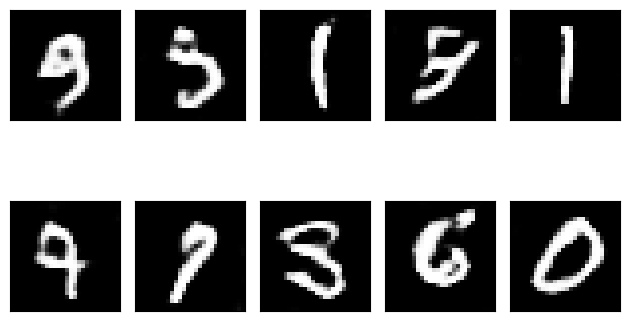

Epoch: 44, disc. loss: 0.6226731538772583, gen. loss: 0.740276575088501. Time for epoch 45 is 44.47412657737732 sec
Epoch: 45, disc. loss: 0.6705827116966248, gen. loss: 0.6581740379333496. Time for epoch 46 is 44.82006287574768 sec
Epoch: 46, disc. loss: 0.6516736745834351, gen. loss: 0.732020378112793. Time for epoch 47 is 44.591862201690674 sec
Epoch: 47, disc. loss: 0.6648446917533875, gen. loss: 0.6627615094184875. Time for epoch 48 is 44.07647633552551 sec
Epoch: 48, disc. loss: 0.657233476638794, gen. loss: 0.7344756126403809. Time for epoch 49 is 45.53874063491821 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


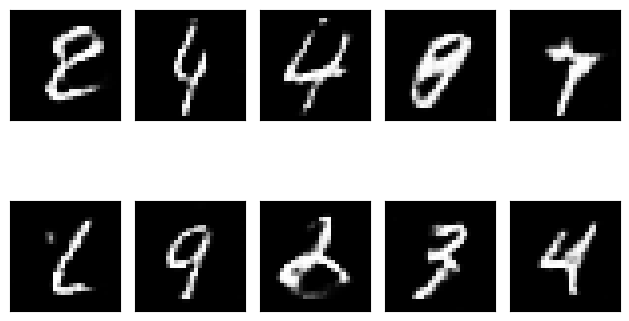

Epoch: 49, disc. loss: 0.6486578583717346, gen. loss: 0.9664269685745239. Time for epoch 50 is 45.29257583618164 sec
Epoch: 50, disc. loss: 0.6854575872421265, gen. loss: 0.806370198726654. Time for epoch 51 is 44.84762620925903 sec
Epoch: 51, disc. loss: 0.6413664221763611, gen. loss: 0.7057684063911438. Time for epoch 52 is 44.746777057647705 sec
Epoch: 52, disc. loss: 0.6956888437271118, gen. loss: 0.6846991777420044. Time for epoch 53 is 44.503562211990356 sec
Epoch: 53, disc. loss: 0.658092737197876, gen. loss: 0.7790569067001343. Time for epoch 54 is 44.59072661399841 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


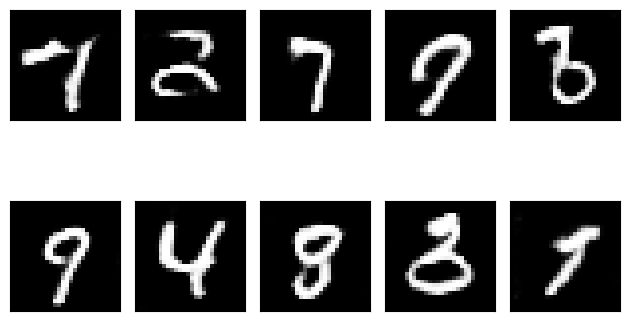

Epoch: 54, disc. loss: 0.6630710959434509, gen. loss: 0.7226282358169556. Time for epoch 55 is 44.72512912750244 sec
Epoch: 55, disc. loss: 0.6432836055755615, gen. loss: 0.8302492499351501. Time for epoch 56 is 43.84355187416077 sec
Epoch: 56, disc. loss: 0.5972975492477417, gen. loss: 0.7875862717628479. Time for epoch 57 is 43.720966815948486 sec
Epoch: 57, disc. loss: 0.6664468050003052, gen. loss: 0.7714389562606812. Time for epoch 58 is 43.50212240219116 sec
Epoch: 58, disc. loss: 0.6636871695518494, gen. loss: 0.7180370092391968. Time for epoch 59 is 43.52981090545654 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


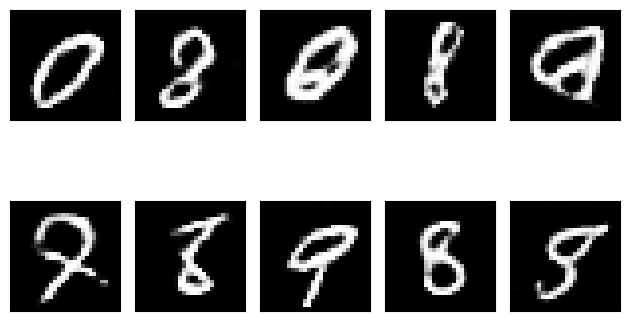

Epoch: 59, disc. loss: 0.6464787125587463, gen. loss: 0.7320922613143921. Time for epoch 60 is 44.07722616195679 sec
Epoch: 60, disc. loss: 0.6590307950973511, gen. loss: 0.7829334139823914. Time for epoch 61 is 43.439162731170654 sec
Epoch: 61, disc. loss: 0.6493366956710815, gen. loss: 0.7613699436187744. Time for epoch 62 is 43.17385959625244 sec
Epoch: 62, disc. loss: 0.6625440120697021, gen. loss: 0.725673258304596. Time for epoch 63 is 43.29911661148071 sec
Epoch: 63, disc. loss: 0.631132960319519, gen. loss: 0.8012698888778687. Time for epoch 64 is 43.24755382537842 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


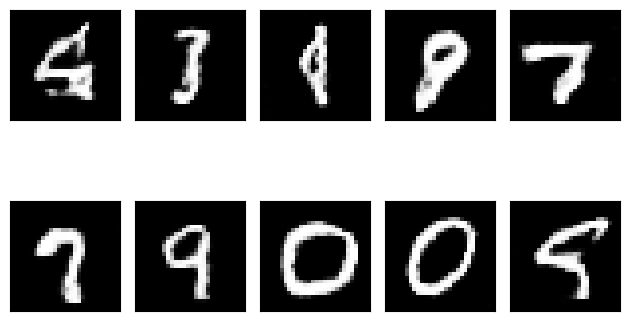

Epoch: 64, disc. loss: 0.6721415519714355, gen. loss: 0.7576872706413269. Time for epoch 65 is 43.47914743423462 sec
Epoch: 65, disc. loss: 0.654263973236084, gen. loss: 0.7629867196083069. Time for epoch 66 is 43.41790819168091 sec
Epoch: 66, disc. loss: 0.6710512638092041, gen. loss: 0.8643398284912109. Time for epoch 67 is 42.85230207443237 sec
Epoch: 67, disc. loss: 0.6513480544090271, gen. loss: 0.7843485474586487. Time for epoch 68 is 42.813496828079224 sec
Epoch: 68, disc. loss: 0.6794726252555847, gen. loss: 0.7265871167182922. Time for epoch 69 is 43.03441619873047 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


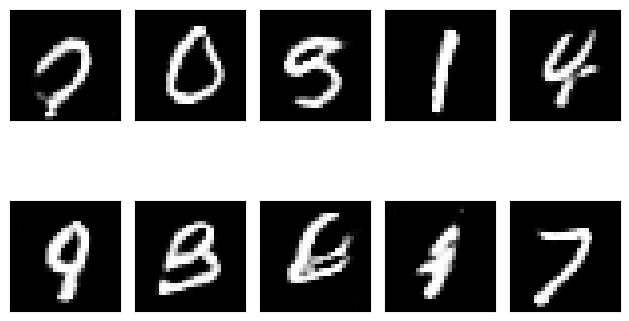

Epoch: 69, disc. loss: 0.6732316017150879, gen. loss: 0.707617998123169. Time for epoch 70 is 43.81391096115112 sec
Epoch: 70, disc. loss: 0.6518389582633972, gen. loss: 0.8692960739135742. Time for epoch 71 is 42.90053606033325 sec
Epoch: 71, disc. loss: 0.6639474630355835, gen. loss: 0.7237110733985901. Time for epoch 72 is 43.01874327659607 sec
Epoch: 72, disc. loss: 0.6555877923965454, gen. loss: 0.7513569593429565. Time for epoch 73 is 43.106019258499146 sec
Epoch: 73, disc. loss: 0.6387636661529541, gen. loss: 0.8159778118133545. Time for epoch 74 is 42.88919973373413 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


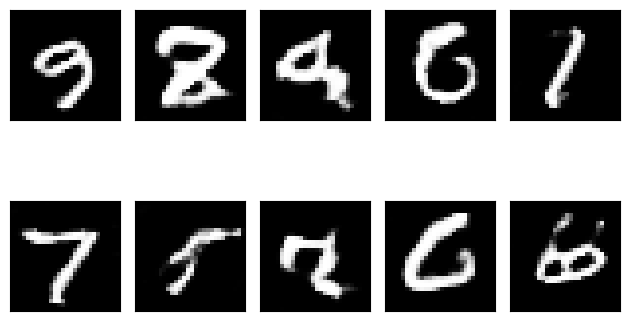

Epoch: 74, disc. loss: 0.6864854097366333, gen. loss: 0.7277916669845581. Time for epoch 75 is 43.454957485198975 sec
Epoch: 75, disc. loss: 0.6738715171813965, gen. loss: 0.6823062896728516. Time for epoch 76 is 43.26679086685181 sec
Epoch: 76, disc. loss: 0.6296741962432861, gen. loss: 0.7617300152778625. Time for epoch 77 is 43.12129259109497 sec
Epoch: 77, disc. loss: 0.6520169973373413, gen. loss: 0.6903752088546753. Time for epoch 78 is 43.62494993209839 sec
Epoch: 78, disc. loss: 0.6605920195579529, gen. loss: 0.7319239377975464. Time for epoch 79 is 43.86016392707825 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


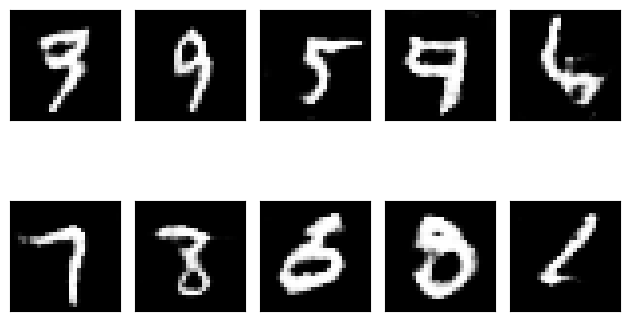

Epoch: 79, disc. loss: 0.6629596948623657, gen. loss: 0.7522740364074707. Time for epoch 80 is 44.401211738586426 sec
Epoch: 80, disc. loss: 0.6542344093322754, gen. loss: 0.8345893025398254. Time for epoch 81 is 43.56580090522766 sec
Epoch: 81, disc. loss: 0.6646409034729004, gen. loss: 0.7141560912132263. Time for epoch 82 is 44.099013566970825 sec
Epoch: 82, disc. loss: 0.6695040464401245, gen. loss: 0.6658515930175781. Time for epoch 83 is 44.482821464538574 sec
Epoch: 83, disc. loss: 0.6584999561309814, gen. loss: 0.7690908312797546. Time for epoch 84 is 45.30191922187805 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


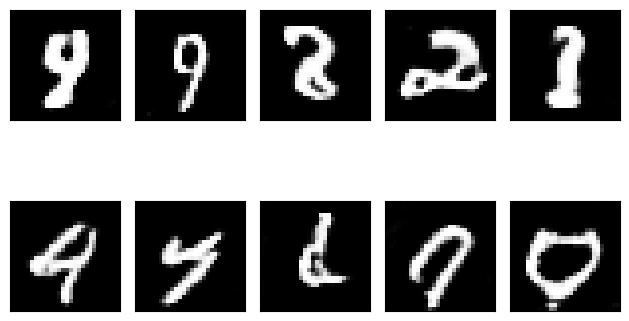

Epoch: 84, disc. loss: 0.7245067954063416, gen. loss: 0.7546004056930542. Time for epoch 85 is 45.254894495010376 sec
Epoch: 85, disc. loss: 0.6673847436904907, gen. loss: 0.7891154885292053. Time for epoch 86 is 44.2237594127655 sec
Epoch: 86, disc. loss: 0.6344871520996094, gen. loss: 0.9549384713172913. Time for epoch 87 is 43.7401659488678 sec
Epoch: 87, disc. loss: 0.6545637249946594, gen. loss: 0.7539806962013245. Time for epoch 88 is 44.40152192115784 sec
Epoch: 88, disc. loss: 0.6597282886505127, gen. loss: 0.8051506280899048. Time for epoch 89 is 44.417903900146484 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


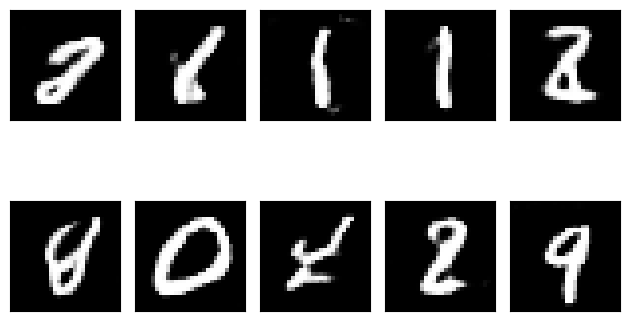

Epoch: 89, disc. loss: 0.6277437806129456, gen. loss: 0.6954879760742188. Time for epoch 90 is 45.00298094749451 sec
Epoch: 90, disc. loss: 0.6695200800895691, gen. loss: 0.7288931012153625. Time for epoch 91 is 43.83407783508301 sec
Epoch: 91, disc. loss: 0.6562891602516174, gen. loss: 0.7636170387268066. Time for epoch 92 is 43.29123568534851 sec
Epoch: 92, disc. loss: 0.6417297720909119, gen. loss: 0.7096962928771973. Time for epoch 93 is 43.857353925704956 sec
Epoch: 93, disc. loss: 0.6304242610931396, gen. loss: 0.7703180909156799. Time for epoch 94 is 43.17253661155701 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


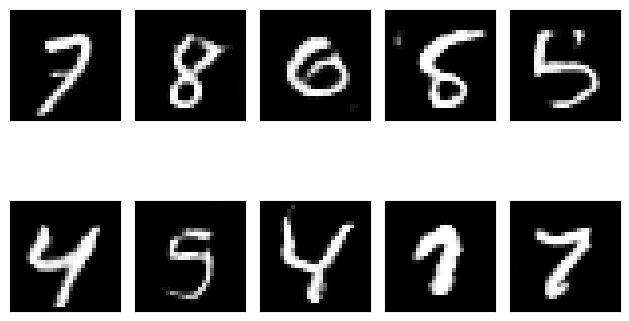

Epoch: 94, disc. loss: 0.6552518606185913, gen. loss: 0.8397745490074158. Time for epoch 95 is 43.28480291366577 sec
Epoch: 95, disc. loss: 0.6913948059082031, gen. loss: 0.7608954906463623. Time for epoch 96 is 42.877864360809326 sec
Epoch: 96, disc. loss: 0.650195837020874, gen. loss: 0.7624733448028564. Time for epoch 97 is 42.784220933914185 sec
Epoch: 97, disc. loss: 0.669143795967102, gen. loss: 0.7092097997665405. Time for epoch 98 is 42.994312047958374 sec
Epoch: 98, disc. loss: 0.6377854347229004, gen. loss: 0.7156109809875488. Time for epoch 99 is 42.81483697891235 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


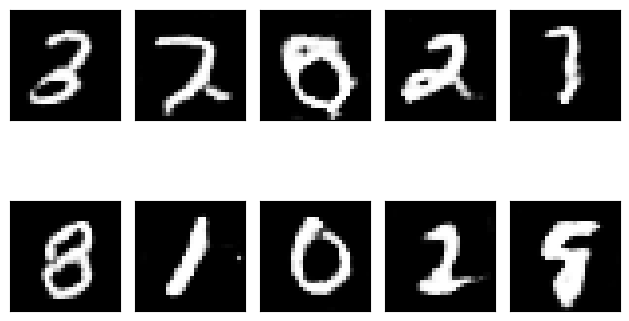

Epoch: 99, disc. loss: 0.6334558129310608, gen. loss: 0.8146823048591614. Time for epoch 100 is 42.89738130569458 sec


In [8]:
import time

# smooth = 0.1
add_noise_labels = True
noise_labels = 0.02

gen_optimizer = Adam( learning_rate=0.0002, beta_1=0.5 )
disc_optimizer = Adam( learning_rate=0.0002, beta_1=0.5 )
# cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
cross_entropy = tf.keras.losses.BinaryCrossentropy()

@tf.function
def train_step( X_real ):
    z = tf.random.normal( [batch_size, latent_dim] )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      X_fake = generator( z, training=True )

      real_output = discriminator( X_real, training=True)
      fake_output = discriminator( X_fake, training=True)

      y_real = tf.ones_like(real_output)
      y_fake = tf.zeros_like(fake_output)
      # Add random noise to the labels
      if add_noise_labels:
          y_real += noise_labels * tf.random.uniform(tf.shape(y_real))
          y_fake += noise_labels * tf.random.uniform(tf.shape(y_fake))
        
      real_loss = cross_entropy( y_real, real_output)
      fake_loss = cross_entropy( y_fake, fake_output)
      disc_loss = 0.5 * ( real_loss + fake_loss )
        
      gen_loss = cross_entropy( tf.ones_like(fake_output), fake_output )

    gen_grads  = gen_tape.gradient( gen_loss, generator.trainable_variables )
    disc_grads = disc_tape.gradient( disc_loss, discriminator.trainable_variables )

    gen_optimizer.apply_gradients( zip( gen_grads, generator.trainable_variables) )
    disc_optimizer.apply_gradients( zip( disc_grads, discriminator.trainable_variables) )

    return (disc_loss, gen_loss)

def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for X_batch in dataset:
      dloss, gloss = train_step( X_batch )

    if (epoch + 1) % 5 == 0:
        samples = 10
        X_ = generator.predict( tf.random.normal( [samples, latent_dim] ) )
        for k in range(samples):
            plt.subplot(2, 5, k+1)
            plt.imshow( X_[k].reshape(28, 28), cmap='gray')
            plt.xticks([])
            plt.yticks([])
        plt.tight_layout()
        plt.show()

    print ( "Epoch: {}, disc. loss: {}, gen. loss: {}.".format( epoch, dloss, gloss ),
            "Time for epoch {} is {} sec".format(epoch + 1, time.time()-start) )
   
epochs = 100
train(train_dataset, epochs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


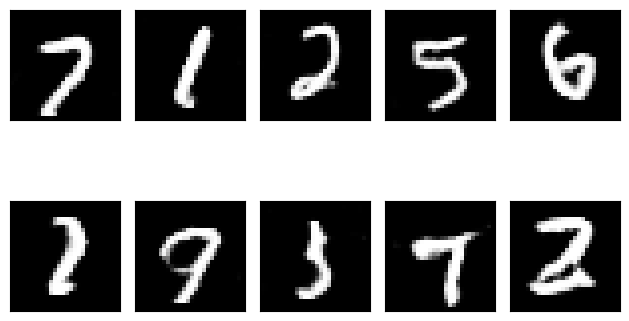

In [17]:
samples = 10
X_ = generator.predict( tf.random.normal( [samples, latent_dim] ) )
for k in range(samples):
    plt.subplot(2, 5, k+1)
    plt.imshow( X_[k].reshape(28, 28), cmap='gray')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()